In [240]:
import pandas as pd

data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\Gene list\consensus_results.Alphaviridae.txt",sep="\t")

In [241]:
from sklearn.preprocessing import normalize

# 標準化後算兩種機器學習的Shapley value的平均
data["RF_mean_nor"] = normalize(
    data[["RF_mean_abs_Score"]],
    axis=0
)

data["XGB_mean_nor"] = normalize(
    data[["XGB_mean_abs_Score"]],
    axis=0
)

data["AVG_mean"] = (data["XGB_mean_nor"] + data["RF_mean_nor"])/2

In [162]:
print(data[["RF_mean_abs_Score","XGB_mean_abs_Score","RF_mean_nor","XGB_mean_nor","AVG_mean"]].head())

   RF_mean_abs_Score  XGB_mean_abs_Score  RF_mean_nor  XGB_mean_nor  AVG_mean
0           0.001713            0.298849     0.180408      0.339429  0.259919
1           0.001408            0.092956     0.148309      0.105579  0.126944
2           0.000821            0.551790     0.086438      0.626718  0.356578
3           0.000929            0.317163     0.097808      0.360231  0.229019
4           0.001024            0.054007     0.107810      0.061341  0.084575


In [ ]:
# 先將想分析的欄位取出來，當作enrichment的ranking，之後可以調整
col = "RF_mean_abs_Score"

rf_rank = data[["Gene",col]]

print(rf_rank.head())

print(len(rf_rank)) # 39376個基因

     Gene  XGB_mean_abs_Score
0   PANK4            0.298849
1    XAB2            0.092956
2  ANAPC2            0.551790
3  P2RY11            0.317163
4    ZASP            0.054007
39376


In [243]:
# 很多基因的數值為0

rf_rank = rf_rank.loc[rf_rank[col] != 0,:]

print(len(rf_rank)) # 6206個基因

114


In [244]:
rf_rank.columns = ["gene", "score"] # 換col名稱 不確定需不需要

rf_rank = rf_rank.sort_values(
    by="score",
    ascending=False
)

print(rf_rank.head())

       gene     score
2    ANAPC2  0.551790
3    P2RY11  0.317163
0     PANK4  0.298849
11  MIR7847  0.282454
19  SNORA63  0.257956


In [245]:
# 取出排名前100的基因
rf_rank_top_100 = rf_rank.iloc[0:100,0:2] 

print(rf_rank_top_100.head())

       gene     score
2    ANAPC2  0.551790
3    P2RY11  0.317163
0     PANK4  0.298849
11  MIR7847  0.282454
19  SNORA63  0.257956


In [246]:
rf_gene_list = rf_rank_top_100["gene"].tolist() # 可以做OSA
print(rf_gene_list[:5])

['ANAPC2', 'P2RY11', 'PANK4', 'MIR7847', 'SNORA63']


In [169]:
import gseapy as gp

# 先做OSA
res = gp.enrichr(
    gene_list=rf_gene_list, 
    gene_sets="KEGG_2021_Human"
)

# 再做GSEA
res_2 = gp.prerank(
    rnk=rf_rank,
    gene_sets="KEGG_2021_Human",
    permutation_num=1000,
    seed=123,
    outdir=None
)

In [170]:
print(res.results.head())

          Gene_set                               Term Overlap   P-value  \
0  KEGG_2021_Human           Homologous recombination    2/41  0.017880   
1  KEGG_2021_Human  Thyroid hormone signaling pathway   3/121  0.022843   
2  KEGG_2021_Human           Apelin signaling pathway   3/137  0.031419   
3  KEGG_2021_Human           ECM-receptor interaction    2/88  0.071834   
4  KEGG_2021_Human               Steroid biosynthesis    1/20  0.095432   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.652054            0                     0   10.392988   
1          0.652054            0                     0    5.184868   
2          0.652054            0                     0    4.562086   
3          0.652054            0                     0    4.701946   
4          0.652054            0                     0   10.569378   

   Combined Score                    Genes  
0       41.821870              TOP3B;XRCC3  
1       19.594255         MED24;MED16;

In [171]:
top20_gene = (
    rf_rank.head(20).copy()
)

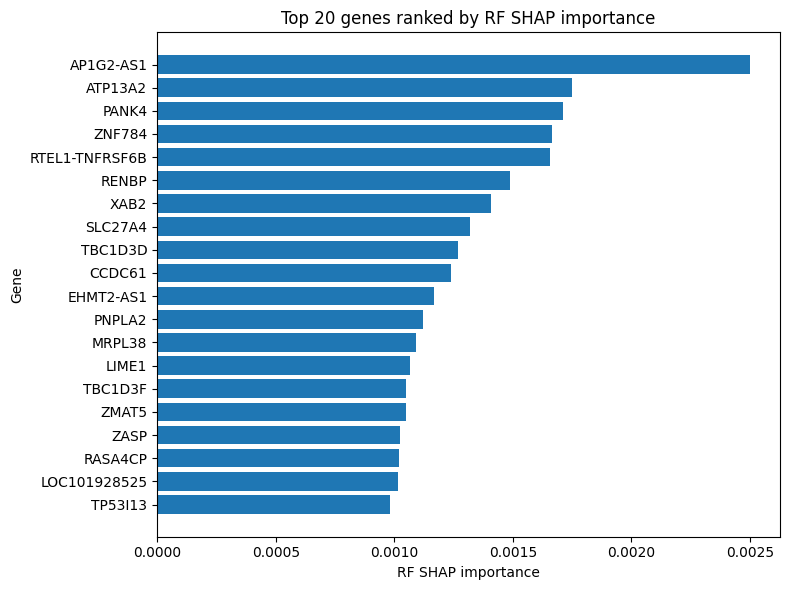

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    top20_gene["gene"][::-1],
    top20_gene["score"][::-1]
)

plt.xlabel("RF SHAP importance")
plt.ylabel("Gene")

plt.title(
    "Top 20 genes ranked by RF SHAP importance"
)

plt.tight_layout()

plt.show()

In [ ]:
shap_rank = (
    data["RF_mean_abs_Score"]
    .sort_values(
        ascending=False
    )
    .reset_index(drop=True)
)


plt.figure(figsize=(8,5))


plt.plot(
    shap_rank
)


plt.xlabel(
    "Gene rank"
)

plt.ylabel(
    "RF SHAP importance"
)


plt.title(
    "Ranked distribution of RF SHAP importance"
)


plt.tight_layout()

plt.show()

In [173]:
ora = res.results.copy()

ora[["Gene_count","Pathway_size"]] = (
    ora["Overlap"]
    .str.split("/", expand=True)
    .astype(int)
)


ora["Gene_ratio"] = (
    ora["Gene_count"] /
    ora["Pathway_size"]
)

In [174]:
ora_top10 = (
    ora
    .sort_values(
        "Adjusted P-value"
    )
    .head(10)
)


ora_top10

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Gene_count,Pathway_size,Gene_ratio
0,KEGG_2021_Human,Homologous recombination,2/41,0.017880,0.652054,0,0,10.392988,41.821870,TOP3B;XRCC3,2,41,0.048780
1,KEGG_2021_Human,Thyroid hormone signaling pathway,3/121,0.022843,0.652054,0,0,5.184868,19.594255,MED24;MED16;HRAS,3,121,0.024793
2,KEGG_2021_Human,Apelin signaling pathway,3/137,0.031419,0.652054,0,0,4.562086,15.786317,BORCS8-MEF2B;MEF2B;HRAS,3,137,0.021898
3,KEGG_2021_Human,ECM-receptor interaction,2/88,0.071834,0.652054,0,0,4.701946,12.382069,GP1BB;COL6A2,2,88,0.022727
4,KEGG_2021_Human,Steroid biosynthesis,1/20,0.095432,0.652054,0,0,10.569378,24.831030,DHCR7,1,20,0.050000
5,KEGG_2021_Human,Arginine biosynthesis,1/22,0.104465,0.652054,0,0,9.561809,21.599228,ACY1,1,22,0.045455
6,KEGG_2021_Human,Terpenoid backbone biosynthesis,1/22,0.104465,0.652054,0,0,9.561809,21.599228,RCE1,1,22,0.045455
7,KEGG_2021_Human,Thermogenesis,3/232,0.110466,0.652054,0,0,2.656688,5.852811,HRAS;ATP5F1D;PNPLA2,3,232,0.012931
8,KEGG_2021_Human,alpha-Linolenic acid metabolism,1/25,0.117846,0.652054,0,0,8.365320,17.888207,PLA2G6,1,25,0.040000
9,KEGG_2021_Human,Glycosylphosphatidylinositol (GPI)-anchor bios...,1/26,0.122262,0.652054,0,0,8.030303,16.876380,PIGQ,1,26,0.038462


In [186]:
ora_top10.columns

Index(['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value',
       'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score',
       'Genes', 'Gene_count', 'Pathway_size', 'Gene_ratio'],
      dtype='object')

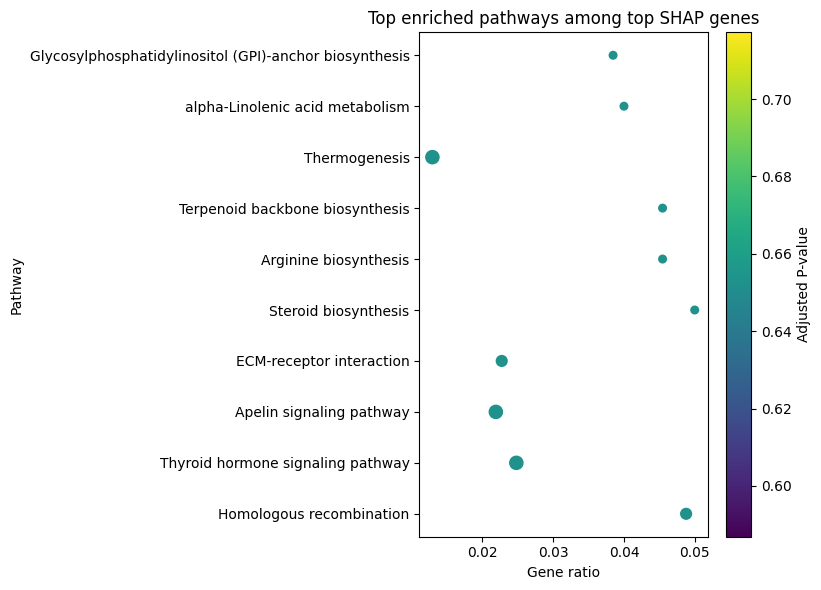

In [191]:
plt.figure(figsize=(8,6))


plt.scatter(
    ora_top10["Gene_ratio"],
    ora_top10["Term"],
    s=ora_top10["Gene_count"]*30,
    c=ora_top10["Adjusted P-value"],
    cmap="viridis"
)


plt.xlabel("Gene ratio")

plt.ylabel("Pathway")

plt.title(
    "Top enriched pathways among top SHAP genes"
)


plt.colorbar(
    label="Adjusted P-value"
)


plt.tight_layout()

plt.show()

In [193]:
gsea = res_2.res2d.copy()

gsea_top = pd.concat([
    gsea.sort_values("NES", ascending=False).head(10),
    gsea.sort_values("NES", ascending=True).head(10)
])

gsea_top["Gene_count"] = (
    gsea_top["Tag %"]
    .str.split("/")
    .str[0]
    .astype(int)
)

gsea_top

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,Gene_count
0,prerank,Inflammatory mediator regulation of TRP channels,0.818059,1.389827,0.049345,1.000000,0.805,3/16,2.40%,PLA2G6;ASIC3;MAPK11,3
1,prerank,Glycerophospholipid metabolism,0.798970,1.364416,0.046138,1.000000,0.896,5/21,8.22%,PLA2G6;PEMT;LCAT;PNPLA7;CDIPT,5
2,prerank,Thermogenesis,0.779149,1.354057,0.013000,1.000000,0.931,6/44,2.40%,PNPLA2;ATP5F1D;HRAS;NDUFS7;SIRT6;MAPK11,6
3,prerank,Neutrophil extracellular trap formation,0.773373,1.353239,0.011000,1.000000,0.934,25/49,13.79%,H2BC15;H4C6;MAPK11;H3C2;H2BC11;H3C11;H4C13;H3C...,25
4,prerank,Systemic lupus erythematosus,0.766627,1.340634,0.018000,1.000000,0.959,22/44,13.79%,H2BC15;H4C6;H3C2;H2BC11;H3C11;H4C13;H3C14;H2BC...,22
5,prerank,Fanconi anemia pathway,0.775635,1.313707,0.090726,1.000000,0.983,5/16,9.47%,TOP3B;TELO2;FAAP100;FANCA;TOP3A,5
6,prerank,Long-term depression,0.765749,1.295579,0.124117,1.000000,0.990,9/15,20.08%,HRAS;GRID2;GNAO1;GUCY1A2;MAPK1;GNAS;GNAI2;GRIA...,9
7,prerank,Alcoholism,0.736715,1.287223,0.016000,1.000000,0.996,35/61,18.95%,H2BC15;HRAS;H4C6;H3C2;H2BC11;GRIN3B;H3C11;H4C1...,35
8,prerank,Shigellosis,0.731237,1.277565,0.024000,1.000000,0.996,26/67,13.21%,MAPK11;H3C2;ATG12;H3C11;RRAGA;H3C14;UBE2D3;PLC...,26
9,prerank,Thyroid hormone signaling pathway,0.736765,1.258667,0.111000,1.000000,0.998,7/25,13.21%,MED16;MED24;HRAS;PLCD3;WNT4;GSK3B;MAPK1,7


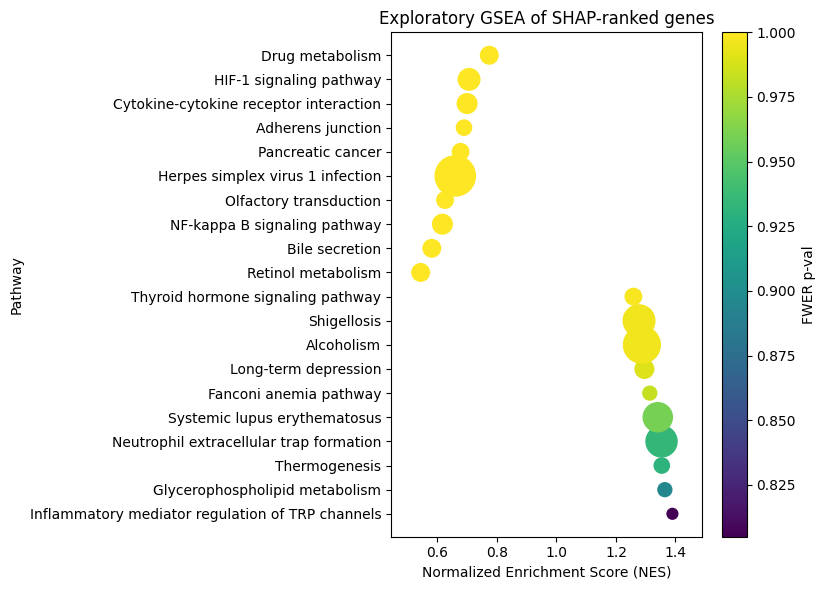

In [212]:
plt.figure(figsize=(8,6))


plt.scatter(
    gsea_top["NES"],
    gsea_top["Term"],
    s=gsea_top["Gene_count"]*20,
    c=gsea_top["FWER p-val"],
    cmap="viridis"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlim(
    gsea_top["NES"].min()-0.1,
    gsea_top["NES"].max()+0.1
)

plt.xlabel(
    "Normalized Enrichment Score (NES)"
)

plt.ylabel(
    "Pathway"
)


plt.title(
    "Exploratory GSEA of SHAP-ranked genes"
)


plt.colorbar(
    label="FWER p-val"
)


plt.tight_layout()

plt.show()

In [200]:
ora_compare = ora[
    [
        "Term",
        "Adjusted P-value"
    ]
].copy()


ora_compare.columns = [
    "Pathway",
    "OSA_FDR"
]

gsea_compare = gsea[
    [
        "Term",
        "NES",
        "FDR q-val",
        "Tag %"
    ]
].copy()


gsea_compare.columns = [
    "Pathway",
    "GSEA_NES",
    "GSEA_FDR",
    "Leading_edge"
]

compare_table = pd.merge(
    ora_compare,
    gsea_compare,
    on="Pathway",
    how="inner"
)

compare_table[["Leading_gene","Pathway_size"]] = (
    compare_table["Leading_edge"]
    .str.split("/", expand=True)
    .astype(int)
)

compare_table["Leading_ratio"] = (
    compare_table["Leading_gene"] /
    compare_table["Pathway_size"]
)

compare_table.sort_values(
    "GSEA_NES",
    ascending=False
).head(20)

,Pathway,OSA_FDR,GSEA_NES,GSEA_FDR,Leading_edge,Leading_gene,Pathway_size,Leading_ratio
40,Inflammatory mediator regulation of TRP channels,0.652054,1.389827,1.0,3/16,3,16,0.187500
39,Glycerophospholipid metabolism,0.652054,1.364416,1.0,5/21,5,21,0.238095
3,Thermogenesis,0.652054,1.354057,1.0,6/44,6,44,0.136364
86,Neutrophil extracellular trap formation,0.697401,1.353239,1.0,25/49,25,49,0.510204
67,Systemic lupus erythematosus,0.652054,1.340634,1.0,22/44,22,44,0.500000
10,Fanconi anemia pathway,0.652054,1.313707,1.0,5/16,5,16,0.312500
14,Long-term depression,0.652054,1.295579,1.0,9/15,9,15,0.600000
11,Alcoholism,0.652054,1.287223,1.0,35/61,35,61,0.573770
0,Thyroid hormone signaling pathway,0.652054,1.258667,1.0,7/25,7,25,0.280000
45,Melanogenesis,0.652054,1.253636,1.0,12/25,12,25,0.480000


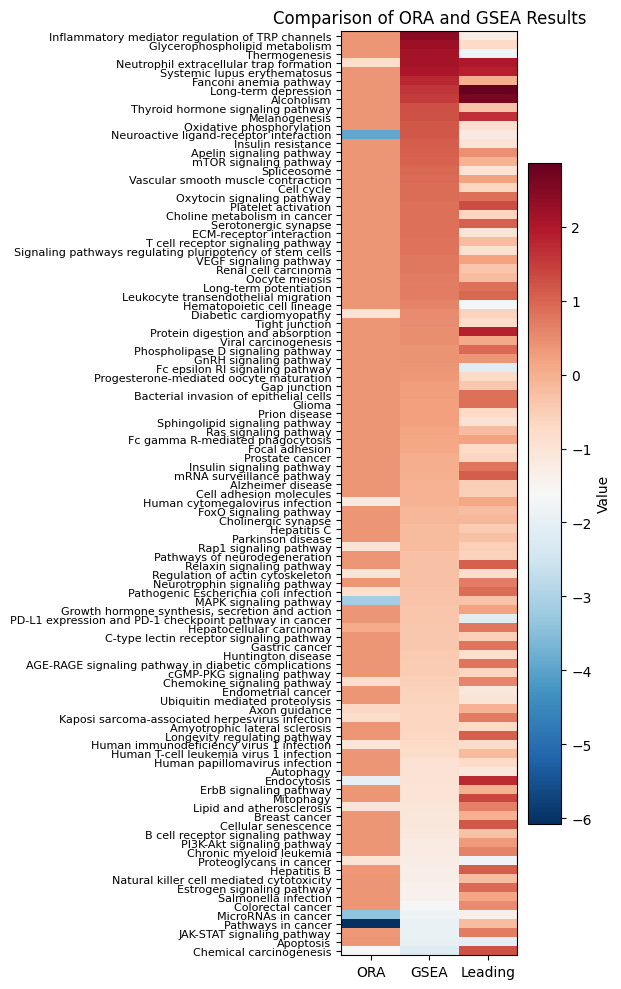

In [ ]:
import numpy as np

heat = (
    compare_table
    .sort_values(
        "GSEA_NES",
        ascending=False
    )
    .copy()
)

heat["ORA"] = -np.log10(
    heat["OSA_FDR"]
)

heat["GSEA"] = heat["GSEA_NES"]

heat["Leading"] = heat["Leading_ratio"]

heat = heat[
    [
        "Pathway",
        "ORA",
        "GSEA",
        "Leading"
    ]
]

heat = heat.set_index(
    "Pathway"
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

heat_scaled = pd.DataFrame(
    scaler.fit_transform(heat),
    index=heat.index,
    columns=heat.columns
)

plt.figure(figsize=(6,10))

plt.imshow(
    heat_scaled,
    aspect="auto",
    cmap="RdBu_r" # 轉成-log10
)

# x 軸
plt.xticks(
    range(len(heat.columns)),
    heat.columns
)

# y 軸
plt.yticks(
    range(len(heat.index)),
    heat.index,
    fontsize=8
)

plt.colorbar(label="Value")

plt.title("Comparison of ORA and GSEA Results")

plt.tight_layout()

plt.show()

Pathways used in network:

Inflammatory mediator regulation of TRP channels
Glycerophospholipid metabolism
Thermogenesis
Neutrophil extracellular trap formation
Systemic lupus erythematosus
Fanconi anemia pathway
Long-term depression
Alcoholism
Thyroid hormone signaling pathway
Melanogenesis
      Gene  Pathway_count  SHAP_importance
9     HRAS              5         0.000419
33   MAPK1              5         0.000067
12  H2BC15              3         0.000441
13    H4C6              3         0.000326
2   MAPK11              3         0.000307
14    H3C2              3         0.000295
15  H2BC11              3         0.000278
16   H3C11              3         0.000230
17   H4C13              3         0.000223
18   H3C14              3         0.000216


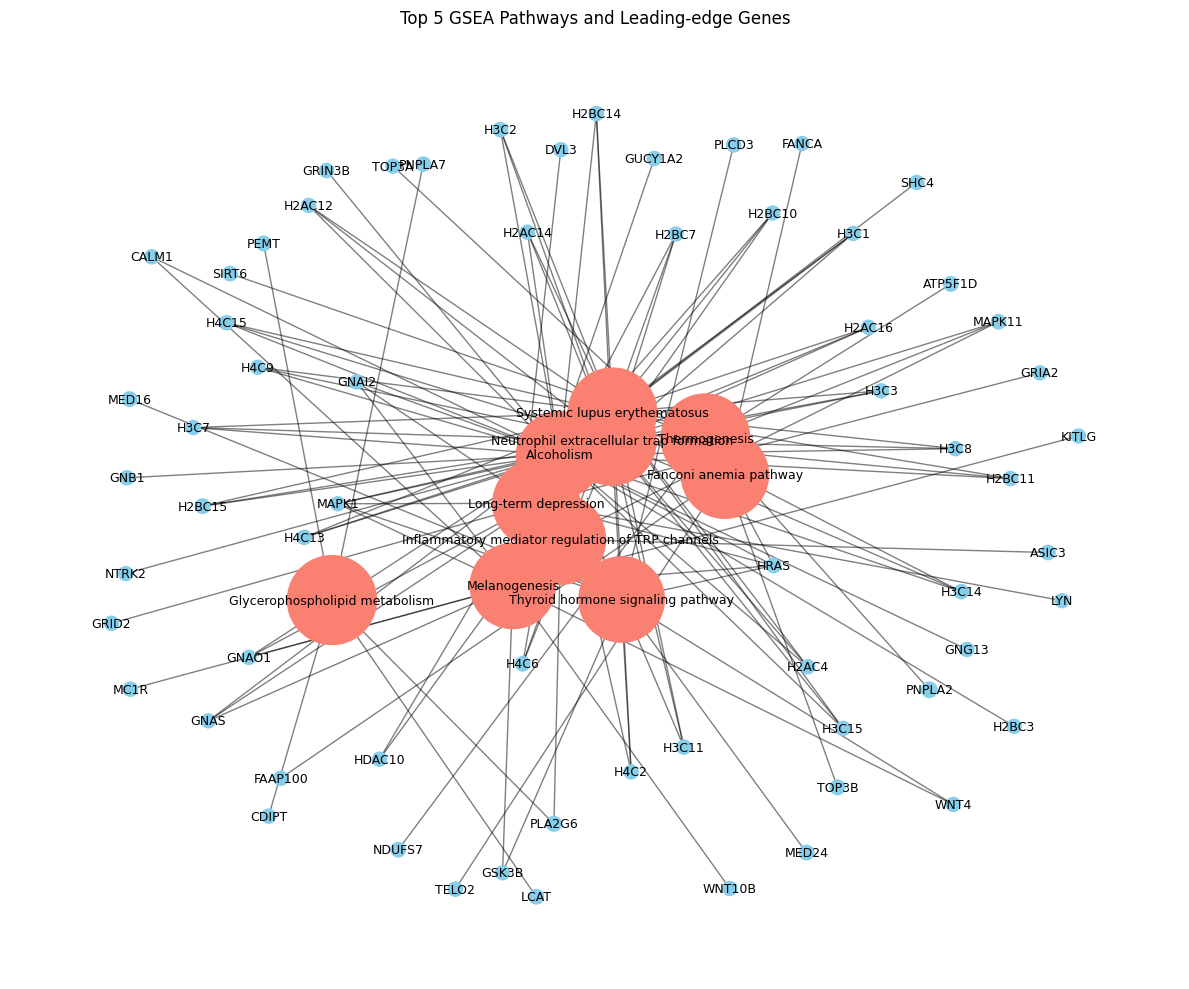

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


##########################################
# 取 GSEA NES 前10個共同 pathway
##########################################

top_pathway = (
    compare_table # 兩種結果共有的pathway
    .sort_values(
        "GSEA_NES",
        ascending=False
    )
    .head(10)["Pathway"]
    .tolist()
)


network_df = gsea[
    gsea["Term"].isin(top_pathway)
].copy()


##########################################
# Gene SHAP importance
##########################################

shap_dict = dict(
    zip(
        data["Gene"],
        data["RF_mean_abs_Score"]
    )
)


##########################################
# Pathway NES
##########################################

nes_dict = dict(
    zip(
        network_df["Term"],
        network_df["NES"]
    )
)


##########################################
# 建立 network
##########################################

G = nx.Graph()


for _, row in network_df.iterrows():

    pathway = row["Term"]

    genes = row["Lead_genes"].split(";")

    for gene in genes:

        G.add_edge(
            gene,
            pathway
        )

##########################################
# 列出使用到的 pathway
##########################################

pathway_nodes = top_pathway

print("Pathways used in network:\n")

for pathway in pathway_nodes:
    print(pathway)


##########################################
# 分類 node
##########################################

gene_nodes = [
    node for node in G.nodes()
    if node in shap_dict
]


pathway_nodes = [
    node for node in G.nodes()
    if node not in shap_dict
]

##########################################
# 計算 gene degree
##########################################

gene_degree = []

for gene in gene_nodes:

    gene_degree.append(
        [
            gene,
            G.degree(gene),
            shap_dict[gene]
        ]
    )


hub_table = pd.DataFrame(
    gene_degree,
    columns=[
        "Gene",
        "Pathway_count",
        "SHAP_importance"
    ]
)


hub_table = (
    hub_table
    .sort_values(
        by=[
            "Pathway_count",
            "SHAP_importance"
        ],
        ascending=False
    )
)


print(
    hub_table.head(10)
)

##########################################
# node size
##########################################

gene_sizes = [
    shap_dict[gene]*20000 + 100
    for gene in gene_nodes
]


pathway_sizes = [
    abs(nes_dict[pathway])*3000
    for pathway in pathway_nodes
]


##########################################
# 畫圖
##########################################

plt.figure(figsize=(12,10))


pos = nx.spring_layout(
    G,
    seed=123,
    k=1
)


# pathway node

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=pathway_nodes,
    node_color="salmon",
    node_size=pathway_sizes
)


# gene node

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=gene_nodes,
    node_color="skyblue",
    node_size=gene_sizes
)


# edges

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)


# labels

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)


plt.title(
    "Top 10 GSEA Pathways and Leading-edge Genes"
)


plt.axis("off")

plt.tight_layout()

plt.show()

In [234]:
top_pathway

['Inflammatory mediator regulation of TRP channels',
 'Glycerophospholipid metabolism',
 'Thermogenesis',
 'Neutrophil extracellular trap formation',
 'Systemic lupus erythematosus',
 'Fanconi anemia pathway',
 'Long-term depression',
 'Alcoholism',
 'Thyroid hormone signaling pathway',
 'Melanogenesis']